>##### 1. Import Libraries

In [1]:
# FasterRCNN with ResNet50 backbone on COCO dataset
# Training, Evaluation (Loss, Accuracy, R2, MAE, MSE), and Grad-CAM Visualization

# %pip install --quiet torch torchvision pycocotools matplotlib opencv-python scikit-learn tqdm grad-cam

# =============================================
# 1. Standard Library
# =============================================
import os
import math
import json
import contextlib
import io
from pathlib import Path
from typing import List, Tuple, Dict

# =============================================
# 2. Third-party Libraries
# =============================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =============================================
# 3. PyTorch & Torchvision
# =============================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import box_iou, nms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.utils import draw_bounding_boxes

# =============================================
# 4. COCO API
# =============================================
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# =============================================
# 5. Grad-CAM
# =============================================
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# =============================================
# 6. Misc
# =============================================
from tqdm import tqdm  # (ถ้าใช้มากกว่า 1 ที่อาจเก็บไว้)


>##### 2. Perform Dataset (COCO format)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "mps" if torch.backends.mps.is_available() else "cpu"  # for Mac M1
print("Device:", device)

def collate_fn(batch):
    return tuple(zip(*batch))

def coco_xywh_to_xyxy(boxes_xywh):
    boxes = torch.as_tensor(boxes_xywh, dtype=torch.float32)
    boxes_xyxy = boxes.clone()
    boxes_xyxy[..., 2] = boxes[..., 0] + boxes[..., 2]
    boxes_xyxy[..., 3] = boxes[..., 1] + boxes[..., 3]
    boxes_xyxy[..., 0] = boxes[..., 0]
    boxes_xyxy[..., 1] = boxes[..., 1]
    return boxes_xyxy

def draw_boxes(img_t, boxes, labels=None, color=(0,255,0), alpha=0.5):
    """img_t: CxHxW tensor [0,1] -> np.uint8 BGR"""
    img = (img_t.permute(1,2,0).cpu().numpy()*255).astype(np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    for i, b in enumerate(boxes):
        x1,y1,x2,y2 = [int(v) for v in b]
        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        if labels is not None:
            cv2.putText(img, str(int(labels[i])), (x1, max(0,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def greedy_match_iou(gt_boxes, pred_boxes, pred_scores, iou_thr=0.5):
    """Greedy match pred->gt by score desc. Returns list of (gt_idx, pred_idx)."""
    if len(gt_boxes)==0 or len(pred_boxes)==0:
        return []
    
    gt_boxes = gt_boxes.to(device)
    pred_boxes = pred_boxes.to(device)
    pred_scores = pred_scores.to(device)
    
    ious = box_iou(gt_boxes, pred_boxes)  # [G,P]
    matched = []
    used_gt = set()
    used_pred = set()
    order = torch.argsort(pred_scores, descending=True)
    for p in order.tolist():
        # pick best gt for this pred
        g = torch.argmax(ious[:, p]).item()
        if g in used_gt:
            continue
        if ious[g, p].item() >= iou_thr:
            matched.append((g, p))
            used_gt.add(g)
            used_pred.add(p)
    return matched


Device: cuda


In [3]:
class COCODetectionWrapper(Dataset):
    def __init__(self, img_dir, ann_file, transforms=None):
        
        super().__init__()
        with contextlib.redirect_stdout(io.StringIO()):
            self.coco = COCO(ann_file)
            
        self.img_dir = img_dir
        self.ids = list(self.coco.getImgIds())
        self.transforms = transforms if transforms is not None else T.ToTensor()

        # map catId -> contiguous [1..NUM_CLASSES] (bg=0)
        cat_ids = self.coco.getCatIds()
        self.catId_to_contig = {cat_id:i+1 for i,cat_id in enumerate(cat_ids)}
        self.contig_to_catId = {v:k for k,v in self.catId_to_contig.items()}
        self.num_classes = len(self.catId_to_contig)
        
        # เพิ่ม catId -> name mapping
        cats = self.coco.loadCats(cat_ids)
        self.catId_to_name = {c['id']: c['name'] for c in cats}
        self.classes = ['bg', 'objects', '1', '10', '2', '5']

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        target_anns = self.coco.loadAnns(ann_ids)
        img_info = self.coco.loadImgs(img_id)[0]
        path = img_info["file_name"]
        img = Image.open(os.path.join(self.img_dir, path)).convert("RGB")
        img = self.transforms(img)

        boxes_xywh = []
        labels = []
        areas = []
        iscrowd = []

        for a in target_anns:
            if a.get("iscrowd", 0) == 1:  # keep but mark
                pass
            boxes_xywh.append(a["bbox"])
            # remap label to contiguous
            labels.append(self.catId_to_contig[a["category_id"]])
            areas.append(a.get("area", a["bbox"][2]*a["bbox"][3]))
            iscrowd.append(a.get("iscrowd", 0))

        if len(boxes_xywh) > 0:
            boxes = coco_xywh_to_xyxy(boxes_xywh)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            areas = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)
        else:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id]),
            "area": areas,
            "iscrowd": iscrowd,
        }
        return img, target


>##### 3. Transforms & Dataloader

In [4]:
def save_prediction_results(img_int, pred_boxes, pred_labels, classes, num):
    save_img = draw_bounding_boxes(
        img_int, pred_boxes, [classes[i] for i in pred_labels], width=1
    ).permute(1, 2, 0)

    save_dir = "/home/mkunnan/project/results"
    os.makedirs(save_dir, exist_ok=True)
    plt.imsave(f"{save_dir}/result_{num}.png", save_img.numpy())

def filter_nms(pred_boxes, pred_labels, pred_scores, iou_threshold, score_threshold):
    # filter low score boxes
    mask = pred_scores > score_threshold
    pred_boxes = pred_boxes[mask]
    pred_labels = pred_labels[mask]
    pred_scores = pred_scores[mask]

    #  nms to remove overlapping boxes
    mask = nms(pred_boxes, pred_scores, iou_threshold)
    pred_boxes = pred_boxes[mask]
    pred_labels = pred_labels[mask]
    pred_scores = pred_scores[mask]
    return pred_boxes, pred_labels, pred_scores

>##### 4. Model (Faster R-CNN, scratch)

In [5]:
SAVE_IMG_DIR = "/home/mkunnan/project/results"
os.makedirs(SAVE_IMG_DIR, exist_ok=True)

In [6]:
# Function to pretty-print Faster R-CNN model architecture
def save_fasterrcnn_structure(model, save_path):
    with open(save_path, "w") as f:
        f.write("========= Faster-RCNN Model Architecture =========\n\n")

        # Backbone
        f.write("=== BACKBONE (Feature Extractor) ===\n")
        f.write(str(model.backbone))
        f.write("\n\n")

        # RPN (Region Proposal Network)
        f.write("=== RPN HEAD ===\n")
        f.write(str(model.rpn))
        f.write("\n\n")

        # ROI Heads (Classification + Box Regression)
        f.write("=== ROI HEADS ===\n")
        f.write(str(model.roi_heads))
        f.write("\n\n")

        f.write("========= END =========\n")


>##### 5. Train One Epoch Function

In [7]:
def train_one_epoch(model, num_epochs, optimizer, data_loader, device, epoch, lr_scheduler=None):
    """
    Train one epoch with tqdm progress bar.
    Returns average epoch loss.
    """
    model.train()
    running_loss, total_box_loss, total_cls_loss, total_dfl_loss = 0.0, 0.0, 0.0, 0.0

    # tqdm bar
    loop = tqdm(enumerate(data_loader), total=len(data_loader), desc=f"Epoch {epoch+1}/{num_epochs}", ncols=50)
    for i, (images, targets) in loop:
        images = [img.to(device) for img in images]
        targets = [{k: (v.to(device) if torch.is_tensor(v) else v) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        box_loss = loss_dict.get("loss_box_reg", 0).item()
        cls_loss = loss_dict.get("loss_classifier", 0).item()
        dfl_loss = loss_dict.get("loss_objectness", 0).item()
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_box_loss += box_loss
        total_cls_loss += cls_loss
        total_dfl_loss += dfl_loss
        
        running_loss += losses.item()
        avg_loss = running_loss / (i+1)

        # อัพเดต tqdm bar ให้โชว์ loss ปัจจุบัน
        loop.set_postfix({"batch_loss": f"{losses.item():.4f}", "avg_loss": f"{avg_loss:.4f}"})

    epoch_loss = running_loss / max(1, len(data_loader))
    avg_box_loss = total_box_loss / max(1, len(data_loader))
    avg_cls_loss = total_cls_loss / max(1, len(data_loader))
    avg_dfl_loss = total_dfl_loss / max(1, len(data_loader))

    if lr_scheduler is not None:
        lr_scheduler.step()
    return {
        "box_loss": avg_box_loss,
        "cls_loss": avg_cls_loss,
        "dfl_loss": avg_dfl_loss,
        "total_loss": avg_box_loss + avg_cls_loss + avg_dfl_loss
    }


>##### 6. Eval Model Function

In [8]:
def evaluate_model(model, data_loader, dataset_wrapper, device, iou_thr=0.5, return_loss=False, coco_gt=None):
    """
    Evaluate Faster-RCNN
    - mAP@0.5
    - Accuracy, MAE, MSE, R2
    - Optional: return average evaluation loss
    """
    model.eval()
    total_loss = 0.0
    num_batches = 0

    total_box_loss = 0.0
    total_cls_loss = 0.0
    total_dfl_loss = 0.0  # (FasterRCNN ไม่มีจริง อาจใช้ objectness loss แทน)
    total_rpn_loss = 0.0

    detections = []
    all_gt_labels, all_pred_labels = [], []

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Evaluating", ncols=50):
            images = [img.to(device) for img in images]
            targets = [{k: (v.to(device) if torch.is_tensor(v) else v) for k,v in t.items()} for t in targets]

            # ✅ Compute Loss in TRAIN mode even during eval
            if return_loss:
                model.train()  # temporarily switch to train mode to compute loss dict
                loss_dict = model(images, targets)
                batch_loss = sum(loss for loss in loss_dict.values())
                total_loss += batch_loss.item()
                num_batches += 1

                total_box_loss += loss_dict.get("loss_box_reg", torch.tensor(0.0)).item()
                total_cls_loss += loss_dict.get("loss_classifier", torch.tensor(0.0)).item()
                total_dfl_loss += loss_dict.get("loss_objectness", torch.tensor(0.0)).item()
                total_rpn_loss += loss_dict.get("loss_rpn_box_reg", torch.tensor(0.0)).item()
                model.eval()  # switch back to eval for prediction

            # Detection
            outputs = model(images)
            for out, tgt in zip(outputs, targets):
                img_id = int(tgt["image_id"].item())
                if len(out["labels"]) == 0:
                    continue
                boxes = out["boxes"].cpu().numpy()
                scores = out["scores"].cpu().numpy()
                labels = out["labels"].cpu().numpy()
                if isinstance(dataset_wrapper, torch.utils.data.Subset):
                    contig_to_cat = dataset_wrapper.dataset.contig_to_catId
                else:
                    contig_to_cat = dataset_wrapper.contig_to_catId
                for b, s, l in zip(boxes, scores, labels):
                    x1,y1,x2,y2 = b.tolist()
                    w = x2 - x1
                    h = y2 - y1
                    detections.append({
                        "image_id": img_id,
                        "category_id": int(contig_to_cat[int(l)]),
                        "bbox": [float(x1), float(y1), float(w), float(h)],
                        "score": float(s),
                    })

                # Pair metrics
                gt_boxes = tgt["boxes"]
                gt_labels = tgt["labels"]
                pred_boxes = out["boxes"].cpu()
                pred_labels = out["labels"].cpu()
                pred_scores = out["scores"].cpu()
                matches = greedy_match_iou(gt_boxes, pred_boxes, pred_scores, iou_thr=iou_thr)
                for g_idx, p_idx in matches:
                    all_gt_labels.append(int(gt_labels[g_idx].item()))
                    all_pred_labels.append(int(pred_labels[p_idx].item()))

    avg_loss = total_loss / max(1, num_batches) if return_loss else None
    avg_box_loss = total_box_loss / max(1, num_batches) if return_loss else None
    avg_cls_loss = total_cls_loss / max(1, num_batches) if return_loss else None
    avg_dfl_loss = total_dfl_loss / max(1, num_batches) if return_loss else None
    avg_rpn_loss = total_rpn_loss / max(1, num_batches) if return_loss else None

    # mAP
    tmp_det_path = "tmp_eval.json"
    with open(tmp_det_path, "w") as f:
        json.dump(detections, f)
        
    # coco_gt = 
    # with contextlib.redirect_stdout(io.StringIO()):  # ปิดการแสดงผล
    if coco_gt is None:
        coco_gt = dataset_wrapper.coco if not isinstance(dataset_wrapper, torch.utils.data.Subset) else dataset_wrapper.dataset.coco
    coco_dt = coco_gt.loadRes(tmp_det_path)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.params.iouThrs = np.array([0.5])

    # val_img_ids = [dataset_wrapper[i]["image_id"].item() for i in val_idx]  # val_idx = index ของ fold ปัจจุบัน
    # val_coco = subset_coco(dataset_wrapper.coco, val_img_ids)

    print("Val subset image_ids:", [t["image_id"].item() for t in targets[:5]])
    print("COCO ground truth IDs:", list(dataset_wrapper.coco.getImgIds()[:5]))
    
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
        
    map50 = float(coco_eval.stats[1])
    precision = len(all_pred_labels) and (np.sum(np.array(all_gt_labels)==np.array(all_pred_labels)) / len(all_pred_labels))   # mAP@0.5:0.95
    recall = coco_eval.stats[8]      # average recall
    map50_95 = coco_eval.stats[0]    # same as precision in this context

    if len(all_gt_labels) == 0:
        acc = mse = mae = r2 = None
    else:
        y_true = np.array(all_gt_labels)
        y_pred = np.array(all_pred_labels)
        acc = (y_true==y_pred).mean()
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2  = r2_score(y_true, y_pred)

    metrics = {
        "mAP@0.5": map50,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "mAP50-95": map50_95,

        "mse": mse,
        "mae": mae,
        "r2": r2,
    }

    if return_loss:
        metrics.update({
            "eval_loss": avg_loss,
            "eval_box_loss": avg_box_loss,
            "eval_cls_loss": avg_cls_loss,
            "eval_dfl_loss": avg_dfl_loss,
            "eval_rpn_loss": avg_rpn_loss,
        })

    return metrics


>##### 7. Training Loop with tqdm

In [9]:
import matplotlib.pyplot as plt
import os

def plt_metrics(
    fold, num_epochs, 
    train_box_losses, train_cls_losses, train_dfl_losses,
    val_box_losses, val_cls_losses, val_dfl_losses,
    val_precision, val_recall, val_map50, val_map50_95,
    save_path=None, show=True
):
    epochs = range(1, num_epochs + 1)
    plt.figure(figsize=(18, 10))  # ขนาดใหญ่เพื่อให้ subplot ชัดเจน

    # --- Training Losses ---
    plt.subplot(2, 5, 1)
    plt.plot(epochs, train_box_losses, 'r-o', label="Box Loss")
    plt.title(f"Fold {fold} - Train Box Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True)

    plt.subplot(2, 5, 2)
    plt.plot(epochs, train_cls_losses, 'g-o', label="Cls Loss")
    plt.title(f"Fold {fold} - Train Cls Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True)

    plt.subplot(2, 5, 3)
    plt.plot(epochs, train_dfl_losses, 'b-o', label="DFL Loss")
    plt.title(f"Fold {fold} - Train DFL Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True)

    # --- Validation Losses ---
    plt.subplot(2, 5, 6)
    plt.plot(epochs, val_box_losses, 'r-o', label="Val Box Loss")
    plt.title(f"Fold {fold} - Val Box Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True)

    plt.subplot(2, 5, 7)
    plt.plot(epochs, val_cls_losses, 'g-o', label="Val Cls Loss")
    plt.title(f"Fold {fold} - Val Cls Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True)

    plt.subplot(2, 5, 8)
    plt.plot(epochs, val_dfl_losses, 'b-o', label="Val DFL Loss")
    plt.title(f"Fold {fold} - Val DFL Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True)


    # --- Metrics ---
    plt.subplot(2, 5, 4)
    plt.plot(epochs, val_precision, 'b-o', label="Precision")
    plt.title(f"Fold {fold} - Val Precision")
    plt.xlabel("Epoch"); plt.ylabel("Precision"); plt.grid(True)

    plt.subplot(2, 5, 5)
    plt.plot(epochs, val_recall, 'c-o', label="Recall")
    plt.title(f"Fold {fold} - Val Recall")
    plt.xlabel("Epoch"); plt.ylabel("Recall"); plt.grid(True)

    plt.subplot(2, 5, 9)
    plt.plot(epochs, val_map50, 'r-o', label="mAP50")
    plt.title(f"Fold {fold} - Val mAP50")
    plt.xlabel("Epoch"); plt.ylabel("mAP50"); plt.grid(True)

    plt.subplot(2, 5, 10)
    plt.plot(epochs, val_map50_95, 'g-o', label="mAP50-95")
    plt.title(f"Fold {fold} - Val mAP50-95")
    plt.xlabel("Epoch"); plt.ylabel("mAP50-95"); plt.grid(True)

    plt.suptitle(f"Fold {fold} Metrics Overview", fontsize=20)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300)
        print(f"Plot saved to: {save_path}")
    if show:
        plt.show()



In [10]:
from pycocotools.coco import COCO
import copy

def subset_coco(coco, indices):
    new_coco = copy.deepcopy(coco)
    img_ids = [coco.getImgIds()[i] for i in indices]
    imgs = [coco.loadImgs(i)[0] for i in img_ids]
    anns = [ann for ann in coco.dataset['annotations'] if ann['image_id'] in img_ids]

    new_coco.dataset['images'] = imgs
    new_coco.dataset['annotations'] = anns
    new_coco.createIndex()
    return new_coco


In [11]:
def train_with_fold(num_epochs, fold, train_loader, val_loader, val_subset, val_idx, model, optimizer, lr_scheduler, device):
# === Train/Validate ===
    CHECKPOINT_DIR = "/home/mkunnan/project/k_fold_checkpoints"
    best_val_loss = float("inf")
    train_losses, train_cls_losses, train_box_losses, train_dfl_losses = [], [], [], []
    val_losses, val_cls_losses, val_box_losses, val_dfl_losses = [], [], [], []

    val_mae, val_mse, val_r2 = [], [], []
    val_map50_95, val_map50, val_precision, val_recall = [], [], [], []
    val_accuracies = [] 

    for epoch in range(num_epochs):
        print(f"\n--- Fold {fold+1} | Epoch {epoch+1}/{num_epochs} ---")

        train_loss = train_one_epoch(
            model=model,
            num_epochs=num_epochs, 
            optimizer=optimizer, 
            data_loader=train_loader, 
            device=device, 
            epoch=epoch, 
            lr_scheduler=lr_scheduler
        )
        train_losses.append(train_loss)
        train_box_losses.append(train_loss.get("box_loss", 0.0))
        train_cls_losses.append(train_loss.get("cls_loss", 0.0))
        train_dfl_losses.append(train_loss.get("dfl_loss", 0.0))

        # val_img_ids = [val_subset[i]["image_id"].item() for i in val_idx]  # val_idx = index ของ fold ปัจจุบัน
        val_img_ids = [val_subset.dataset[idx][1]["image_id"].item() for idx in val_subset.indices]
        # [val_subset.dataset[indx][1]["image_id"].item() for indx in val_subset.indices[:10]]
        val_coco = subset_coco(val_subset.coco, val_img_ids)

        metrics = evaluate_model(model, val_loader, val_subset, device, return_loss=True, coco_gt=val_coco)

        # val_loss = metrics.get("eval_loss", None)
        # val_box_loss = metrics.get("eval_box_loss", 0.0)

        val_loss = metrics.get("eval_loss", None)
        val_losses.append(val_loss)
        val_box_losses.append(metrics.get("eval_box_loss", 0.0))
        val_cls_losses.append(metrics.get("eval_cls_loss", 0.0))
        val_dfl_losses.append(metrics.get("eval_dfl_loss", 0.0))

        val_map50_95.append(metrics.get("mAP50-95", 0.0))
        val_map50.append(metrics.get("mAP@0.5", 0.0))
        val_precision.append(metrics.get("precision", 0.0))
        val_recall.append(metrics.get("recall", 0.0))
        val_accuracies.append(metrics.get("accuracy", 0.0))

        val_mae.append(metrics.get("mae", 0.0))
        val_mse.append(metrics.get("mse", 0.0))
        val_r2.append(metrics.get("r2", 0.0))

        print(f"[Fold {fold+1}] [Epoch {epoch+1}] Eval metrics: {metrics}\n\n")

        checkpoint_path = os.path.join(CHECKPOINT_DIR, f"model_fold_{fold+1}_epoch_{epoch+1}.pt")
        save_dict = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            # "train_loss": train_loss,
            # "val_loss": val_loss,
            "train_metrics": {
                "train_loss": train_loss,
                "train_box_loss": train_loss.get("box_loss", 0.0),
                "train_cls_loss": train_loss.get("cls_loss", 0.0),
                "train_dfl_loss": train_loss.get("dfl_loss", 0.0)
            },
            "val_metrics": {
                "val_loss": val_loss,
                "val_box_loss": metrics.get("eval_box_loss", 0.0),
                "val_cls_loss": metrics.get("eval_cls_loss", 0.0),
                "val_dfl_loss": metrics.get("eval_dfl_loss", 0.0),
                "val_rpn_loss": metrics.get("eval_rpn_loss", 0.0),
                "val_map50_95": metrics.get("mAP50-95", 0.0),
                "val_map50": metrics.get("mAP@0.5", 0.0),
                "val_precision": metrics.get("precision", 0.0),
                "val_recall": metrics.get("recall", 0.0),
                "val_accuracy": metrics.get("accuracy", 0.0),
                "val_mae": metrics.get("mae", 0.0),
                "val_mse": metrics.get("mse", 0.0),
                "val_r2": metrics.get("r2", 0.0),
            }
        }
        torch.save(save_dict, checkpoint_path)

        # Save best checkpoint
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(save_dict, f"{CHECKPOINT_DIR}/best_fold{fold+1}.pt")

    # === บันทึกผลของแต่ละ fold ===
    plt_metrics(
        fold+1,
        num_epochs, 
        train_box_losses,
        train_cls_losses,
        train_dfl_losses,
        val_box_losses,
        val_cls_losses,
        val_dfl_losses,
        val_precision,
        val_recall,
        val_map50,
        val_map50_95,
        save_path=f"{SAVE_IMG_DIR}/fold_{fold+1}_metrics.png",
        show=False
    )
    avg_acc = np.mean(val_accuracies)
    avg_loss = np.mean(val_losses)

    print(f"==> Fold {fold+1} Summary: avg_acc={avg_acc:.4f}, avg_loss={avg_loss:.4f}")
    return avg_acc, avg_loss


In [ ]:
import os
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
import torch.optim as optim
import numpy as np

class SubsetWithAttr(torch.utils.data.Subset):
    def __getattr__(self, name):
        return getattr(self.dataset, name)

# === ตั้งค่าเบื้องต้น ===
DATASET_ROOT = "/home/mkunnan/project/cocoJaa"
TRAIN_IMG_DIR = f"{DATASET_ROOT}/train"
TRAIN_ANN = f"{DATASET_ROOT}/train/_annotations.coco.json"

TEST_IMG_DIR = f"{DATASET_ROOT}/test"
TEST_ANN = f"{DATASET_ROOT}/test/_annotations.coco.json"

NUM_CLASSES = 5  # จำนวนคลาสไม่รวม background
NUM_FOLDS = 5    # จำนวน fold ที่ต้องการ
num_epochs = 12
BATCH_SIZE = 16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = T.Compose([
    T.ToTensor(),
])


Dataset size: 3750

========== Fold 4/5 ==========

--- Fold 4 | Epoch 1/12 ---


Epoch 1/12: 100%|█| 188/188 [01:27<00:00,  2.14it/


creating index...
index created!


Evaluating: 100%|█| 47/47 [00:25<00:00,  1.87it/s]


Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Val subset image_ids: [3671, 3686, 3688, 3694, 3701]
COCO ground truth IDs: [0, 1, 2, 3, 4]
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.34s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.821
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.821
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.823
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.798
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.539
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.991
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   al

...

Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Val subset image_ids: [3689, 3693, 3698, 3700, 3703]
COCO ground truth IDs: [0, 1, 2, 3, 4]
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.53s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.973
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.973
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.955
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.974
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.533
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.990
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   al

Epoch 12/12: 100%|█| 188/188 [01:33<00:00,  2.01it


creating index...
index created!


Evaluating: 100%|█| 47/47 [00:26<00:00,  1.79it/s]


Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Val subset image_ids: [3689, 3693, 3698, 3700, 3703]
COCO ground truth IDs: [0, 1, 2, 3, 4]
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.52s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.973
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.973
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.955
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.974
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.533
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.990
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   al

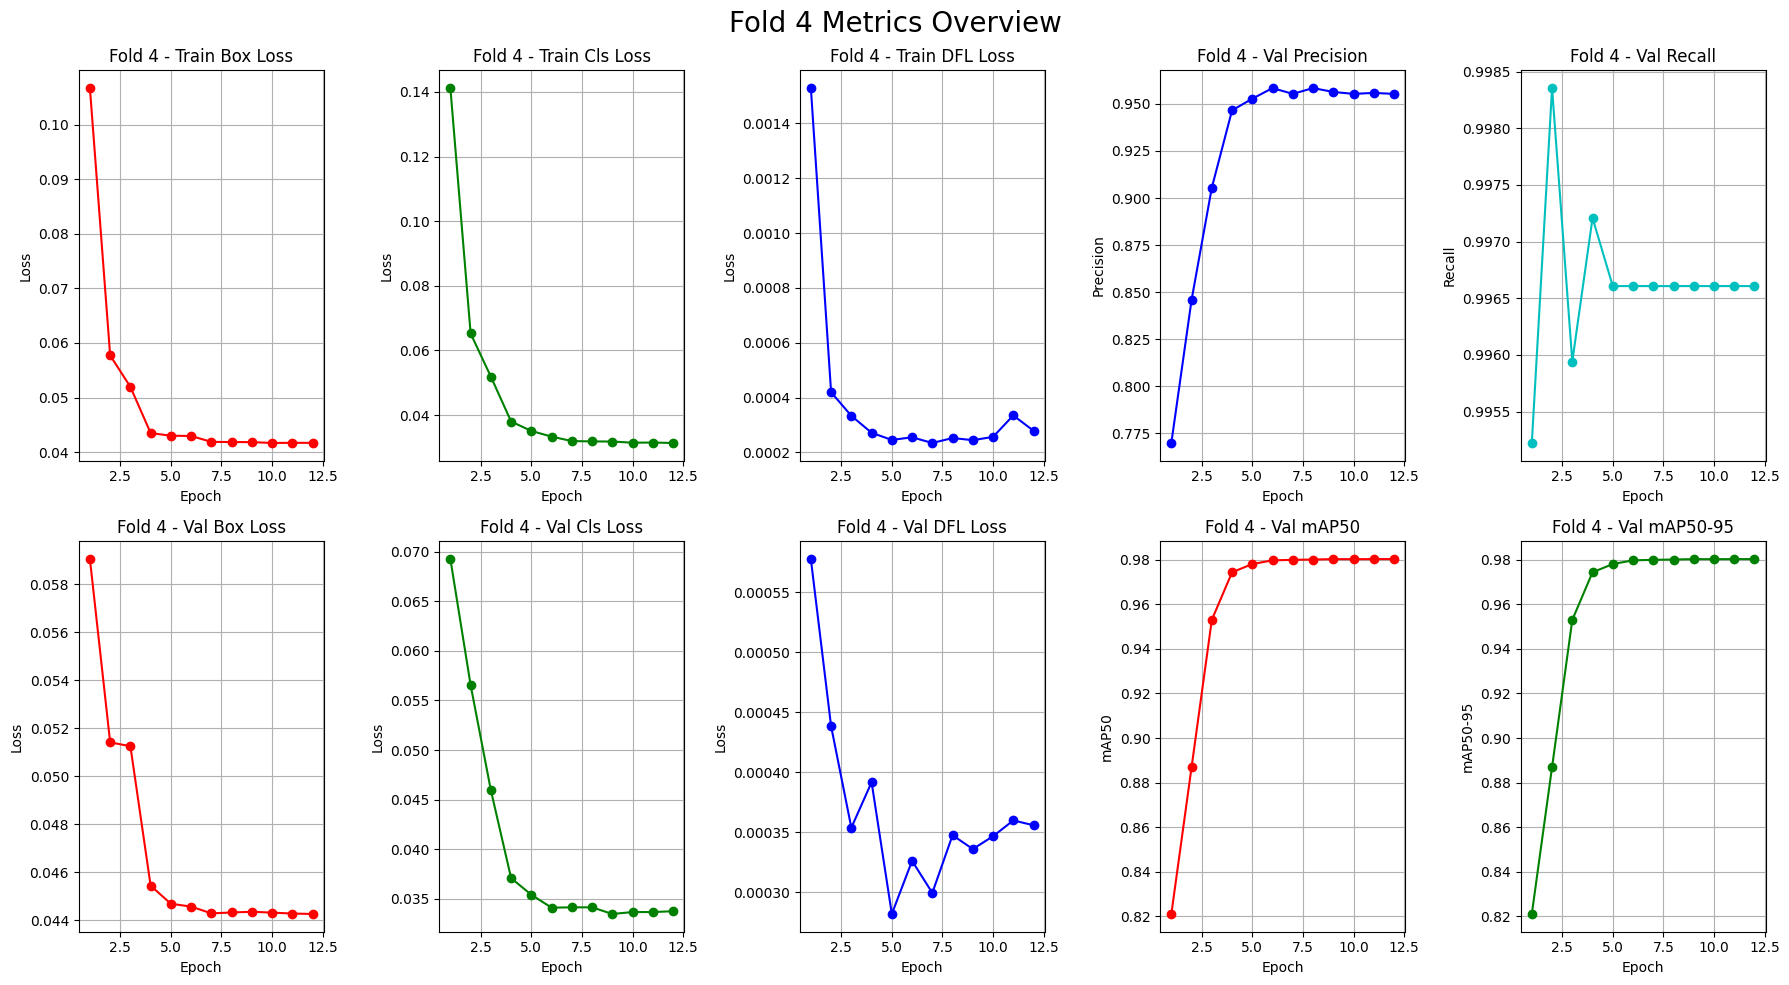

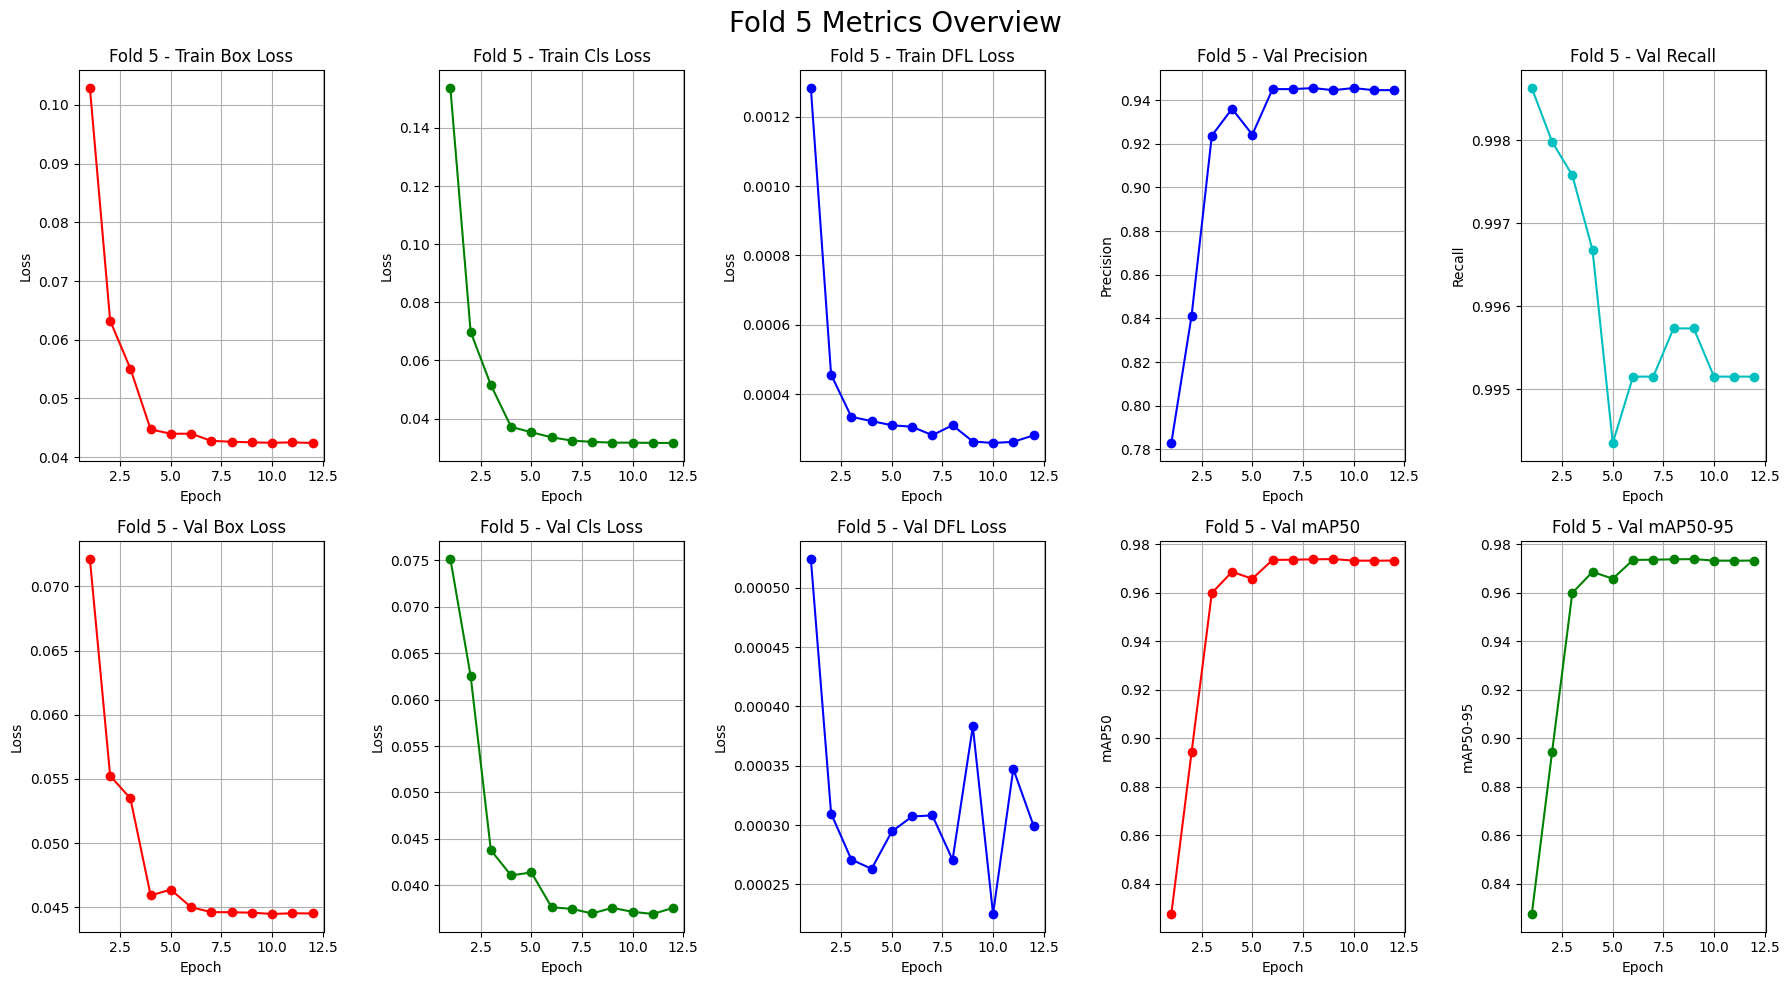

In [ ]:
# === โหลด dataset เดียว (ไม่ต้องแยก valid/test) ===
dataset = COCODetectionWrapper(TRAIN_IMG_DIR, TRAIN_ANN, transforms=transform)
print("Dataset size:", len(dataset))

# === ตั้งค่า KFold ===
kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
start_fold = 4

# === เริ่มทำ K-Fold Cross Validation ===
fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    if fold < start_fold-1:
        continue
    print(f"\n========== Fold {fold+1}/{NUM_FOLDS} ==========")
    
    # แยก subset สำหรับ train / validation
    train_subset = SubsetWithAttr(dataset, train_idx)
    val_subset = SubsetWithAttr(dataset, val_idx)

    # สร้าง dataloader
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, collate_fn=collate_fn)
    val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, collate_fn=collate_fn)

    # === สร้าง model ใหม่ทุก fold ===
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES + 1)
    model.to(device)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    # === Train/Validate ===
    fold_result = train_with_fold(num_epochs, fold, train_loader, val_loader, val_subset, val_idx, model, optimizer, lr_scheduler, device)
    fold_results.append(fold_result)

    # print(val_subset.dataset[0][0]["image_id"])
    # break

# === สรุปผลทุก fold ===
# print("\n========= Cross Validation Results =========")
# for i, (acc, loss) in enumerate(fold_results):
#     print(f"Fold {i+1}: acc={acc:.4f}, loss={loss:.4f}")
# print("Average accuracy:", np.mean([a for a, _ in fold_results]))


In [ ]:
# print(val_subset.indices, len(val_subset.indices))
# []
# print(val_subset.coco.getImgIds()[:5])
# print(val_subset.dataset[:10][1]["image_id"])
# print(len(val_subset.dataset))
# [val_subset.dataset[indx][1]["image_id"].item() for indx in val_subset.indices[:10]]
val_img_ids = [val_subset.dataset[idx][1]["image_id"].item() for idx in val_subset.indices]
# [val_subset.dataset[indx][1]["image_id"].item() for indx in val_subset.indices[:10]]
val_coco = subset_coco(val_subset.coco, val_img_ids)

creating index...
index created!


In [ ]:
val_coco.dataset['images'][:2]

[{'id': 1,
  'license': 1,
  'file_name': 'IMG_3133_aug2_jpg.rf.ea98e472f04a9c36a3698d8b72a2897c.jpg',
  'height': 640,
  'width': 640,
  'date_captured': '2025-10-08T09:11:44+00:00',
  'extra': {'user_tags': ['rd'], 'name': 'IMG_3133_aug2.jpg'}},
 {'id': 4,
  'license': 1,
  'file_name': 'z5388399201321_a5232411b6cfdeecb0880992716aabdd_jpg.rf.17371f1bd38e556fdb3adcc79dddfd3e.jpg',
  'height': 640,
  'width': 640,
  'date_captured': '2025-10-08T09:11:44+00:00',
  'extra': {'name': 'z5388399201321_a5232411b6cfdeecb0880992716aabdd_jpg'}}]

>##### 7. Plot Loss Graph

In [ ]:
# def plt_metrics(num_epochs, train_losses, val_losses, val_accuracies, val_mae, val_mse, val_r2):
#     epochs = range(1, num_epochs+1)

#     plt.figure(figsize=(18,5))

#     plt.subplot(1,5,1)
#     plt.plot(epochs, train_losses, label="Train Loss")
#     plt.plot(epochs, val_losses, label="Val Loss")
#     plt.title("Loss")
#     plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
#     plt.ylim(0, max(max(train_losses), max(val_losses))*1.2)

#     plt.subplot(1,5,2)
#     plt.plot(epochs, val_accuracies, 'g-o')
#     plt.title("Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")

#     plt.subplot(1,5,3)
#     plt.plot(epochs, val_mae, 'r-o')
#     plt.title("MAE"); plt.xlabel("Epoch"); plt.ylabel("MAE")

#     plt.subplot(1,5,4)
#     plt.plot(epochs, val_mse, 'b-o')
#     plt.title("MSE"); plt.xlabel("Epoch"); plt.ylabel("MSE")

#     plt.subplot(1,5,5)
#     plt.plot(epochs, val_r2, 'm-o')
#     plt.title("R²"); plt.xlabel("Epoch"); plt.ylabel("R²")

#     plt.tight_layout()
#     plt.show()

>##### 8. Evaluate Test set (MAE, MSE, R²)

In [ ]:
# ----------------------
# Load the best checkpoint
CHECKPOINT_DIR = "/home/mkunnan/project/k_fold_checkpoints"
best_checkpoint_path = os.path.join(CHECKPOINT_DIR, "best_fold4.pt")

checkpoint = torch.load(best_checkpoint_path, map_location=device)

model = fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES + 1)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

test_dataset = COCODetectionWrapper(
    img_dir=TEST_IMG_DIR,
    ann_file=TEST_ANN,
    transforms=transform
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, collate_fn=collate_fn)
# ----------------------
# Evaluate on test dataset
test_metrics = evaluate_model(model, test_loader, test_dataset, device, return_loss=True, coco_gt=None)
print("Finish Testing")

/tmp/ipykernel_3711530/4247388779.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_checkpoint_path, map_location=device)
Evaluating: 100%|█| 

Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Val subset image_ids: [496, 497, 498, 499]
COCO ground truth IDs: [0, 1, 2, 3, 4]
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.44s).
Accumulating evaluation results...
DONE (t=0.04s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.983
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.983
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.979
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.985
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.592
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.992
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets

In [ ]:
print("===> Test Metrics:")
test_metrics_values = {}
for k,v in test_metrics.items():
    print(f"{k}: {v}")
    test_metrics_values[k] = v

epochs = range(1, num_epochs+1)

===> Test Metrics:
mAP@0.5: 0.9832216757027021
accuracy: 0.9646643109540636
precision: 0.9646643109540636
recall: 0.9942242319959711
mAP50-95: 0.9832216757027021
mse: 0.26943462897526504
mae: 0.09452296819787986
r2: 0.7975948931490274
eval_loss: 0.05011339095653966
eval_box_loss: 0.023600032785907388
eval_cls_loss: 0.02564561550389044
eval_dfl_loss: 0.00025983057643941265
eval_rpn_loss: 0.0006079118666093564


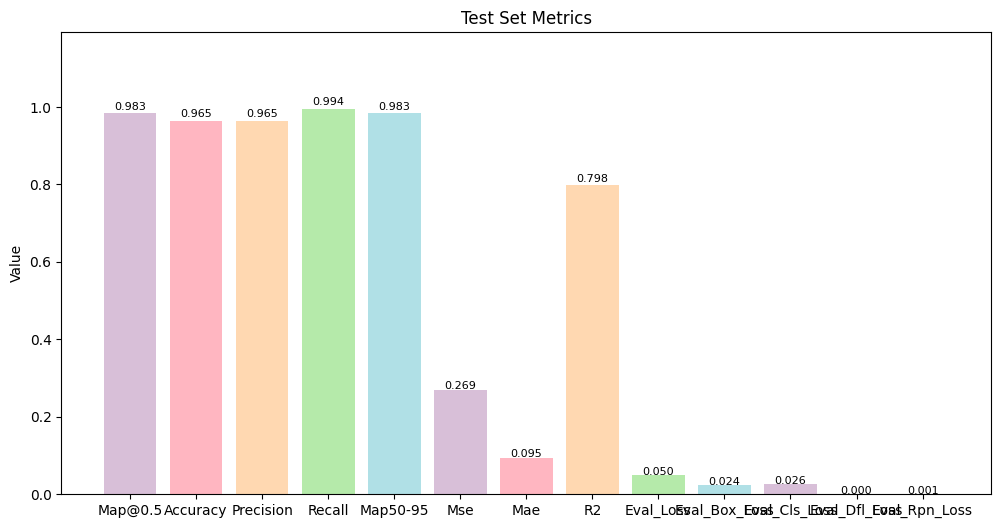

In [ ]:
metrics_names = list(test_metrics_values.keys())
metrics_names = [name.title() for name in metrics_names]
metrics_vals  = list(test_metrics_values.values())

colors = ['#D8BFD8', '#FFB6C1', '#FFD8B1', '#B5EAAA', '#B0E0E6']  # loss, accuracy, mae, mse, r2
plt.figure(figsize=(12, 6))
bars = plt.bar(metrics_names, metrics_vals, color=colors)

# เพิ่มค่าเหนือแท่ง
for bar, val in zip(bars, metrics_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01, f"{val:.3f}", ha='center', fontsize=8)

plt.title("Test Set Metrics")
plt.ylabel("Value")
plt.ylim(0, max(metrics_vals)*1.2)  # เพิ่ม margin บน
# plt.tight_layout()
plt.show()


>##### 9. Grad-CAM Visualization

In [ ]:
def visualize_gradcam_backbone(image_tensor, target_layer, device, title="Grad-CAM Backbone"):
    """
    Grad-CAM สำหรับ FasterRCNN backbone
    ใช้ feature map ของ backbone โดยตรง
    """
    rgb_img = image_tensor.permute(1,2,0).cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    input_tensor = image_tensor.unsqueeze(0).to(device)

    # hook เก็บ feature map
    activations = []
    def forward_hook(module, inp, out):
        activations.append(out)
    handle = target_layer.register_forward_hook(forward_hook)

    with torch.no_grad():
        _ = model(input_tensor)

    handle.remove()

    feature_map = activations[0][0].cpu().numpy()  # [C,H_feat,W_feat]
    cam = feature_map.mean(axis=0)  # [H_feat, W_feat]

    # resize CAM ให้ตรงกับภาพ
    cam = cv2.resize(cam, (rgb_img.shape[1], rgb_img.shape[0]))
    cam = (cam - cam.min()) / (cam.max() - cam.min())

    visualization = show_cam_on_image(rgb_img, cam, use_rgb=True)
    return visualization


>##### 10. Visualize Gradcam

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Using classes:  ['bg', 'objects', '1', '10', '2', '5']


/tmp/ipykernel_3944044/3703896533.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_int = torch.tensor(img * 255, dtype=torch.uint8)


Correct prediction: [3] [3]
File name: one-back-00003_aug3_jpg.rf.e14071ec3d4fbb9087dd90346bfda330.jpg Image ID: 988
False prediction: [2] [5]


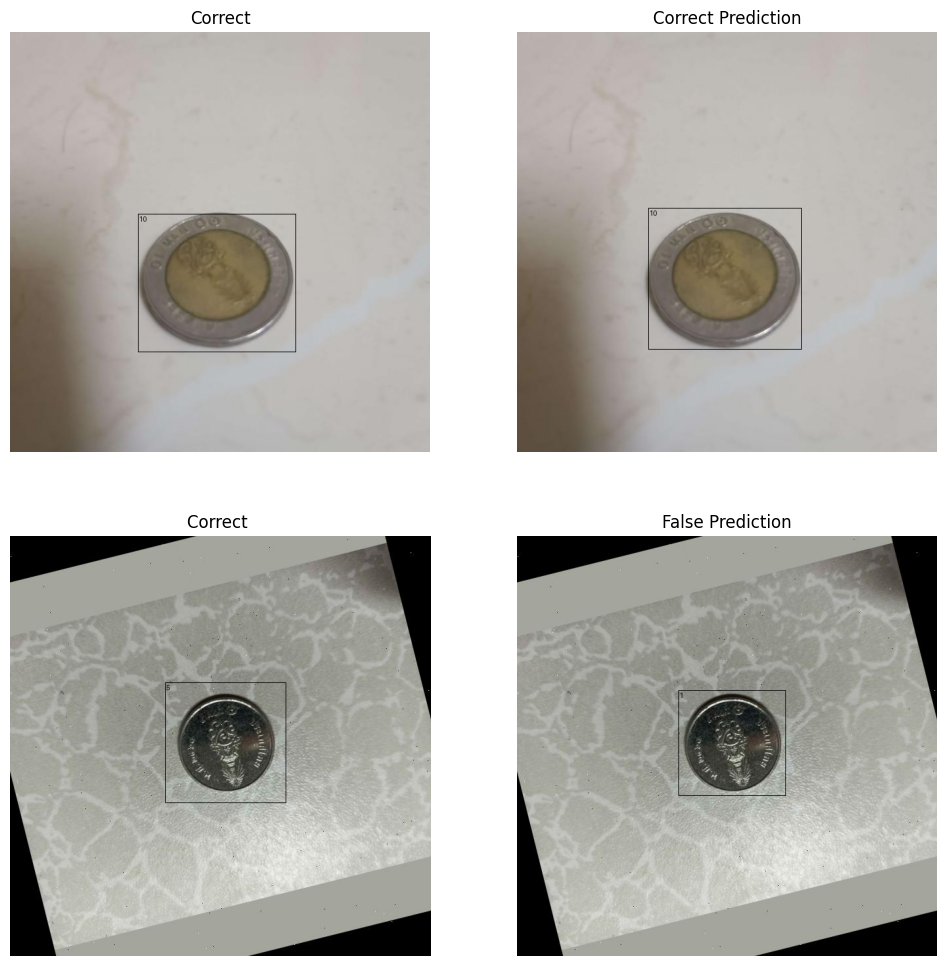

In [ ]:

# for imgs, targets in val_loader:
#     img_tensor = imgs[0].to(device)
#     visualize_gradcam_backbone(img_tensor, target_layer, device)
#     break

correct = False
correct_img = None
false_pos = False
false_pos_img = None

# test = val_dataset[0]
# โหลด category names แบบอัตโนมัติจาก COCO
coco = COCO(TRAIN_ANN)
cat_ids = coco.getCatIds()
cats = coco.loadCats(cat_ids)

# --- Classes for visualization / drawing ---
classes = train_dataset.classes
print("Using classes: ", classes)

# classes = ['objects', 'bg', '1', '10', '2', '5']
model.eval()
target_layer = model.backbone.body.layer4[-1] # last block of layer4

fig, ax = plt.subplots(2, 2, figsize=(12, 12))
ax[0, 0].set_title("Correct")
ax[0, 0].axis("off")
ax[0, 1].set_title("Correct Prediction")
ax[0, 1].axis("off")
ax[1, 0].set_title("Correct ")
ax[1, 0].axis("off")
ax[1, 1].set_title("False Prediction")
ax[1, 1].axis("off")
i = 0

score_threshold = 0.6
iou_threshold = 0.5


for img, target in train_dataset:
    i += 1
    if len(target["labels"]) != 1:
        continue

    gt_labels = target["labels"].cpu().numpy()

    img_cuda = img.to(device)
    with torch.no_grad():
        output = model([img_cuda])[0]

    pred_boxes = output["boxes"].cpu()
    pred_labels = output["labels"].cpu().numpy()
    pred_scores = output["scores"].cpu()
    # pred_boxes, pred_labels, pred_scores = filter_nms(pred_boxes, pred_labels, pred_scores, iou_threshold, score_threshold)

    if len(pred_labels) != 1:
        continue

    img_int = torch.tensor(img * 255, dtype=torch.uint8)


    if pred_labels[0] == gt_labels[0] and not correct:
        correct = True
        correct_img = img

        print("Correct prediction:", pred_labels, gt_labels)
        ax[0, 0].imshow(draw_bounding_boxes(
            img_int, target["boxes"], [classes[i] for i in target["labels"]], width=1
        ).permute(1, 2, 0))
        ax[0, 1].imshow(draw_bounding_boxes(
            img_int, pred_boxes, [classes[i] for i in pred_labels], width=1
        ).permute(1, 2, 0))

    elif pred_labels[0] != gt_labels[0] and not false_pos:
        false_pos = True
        false_pos_img = img
        
        img_id = int(target["image_id"].item())
        img_info = train_dataset.coco.loadImgs(img_id)[0]
        file_name = img_info["file_name"]
        print("File name:", file_name, "Image ID:", img_id)

        print("False prediction:", pred_labels, gt_labels)
        ax[1, 0].imshow(draw_bounding_boxes(
            img_int, target["boxes"], [classes[i] for i in target["labels"]], width=1
        ).permute(1, 2, 0))
        ax[1, 1].imshow(draw_bounding_boxes(
            img_int, pred_boxes, [classes[i] for i in pred_labels], width=1
        ).permute(1, 2, 0))
        
    # if correct and false_pos:
    #     print("end loop")
    #     break
# {'boxes': tensor([[100.5663, 132.9429, 173.0736, 189.9566]], device='cuda:0',
#    grad_fn=<StackBackward0>), 'labels': tensor([3], device='cuda:0'), 'scores': tensor([0.9986], device='cuda:0', grad_fn=<IndexBackward0>)


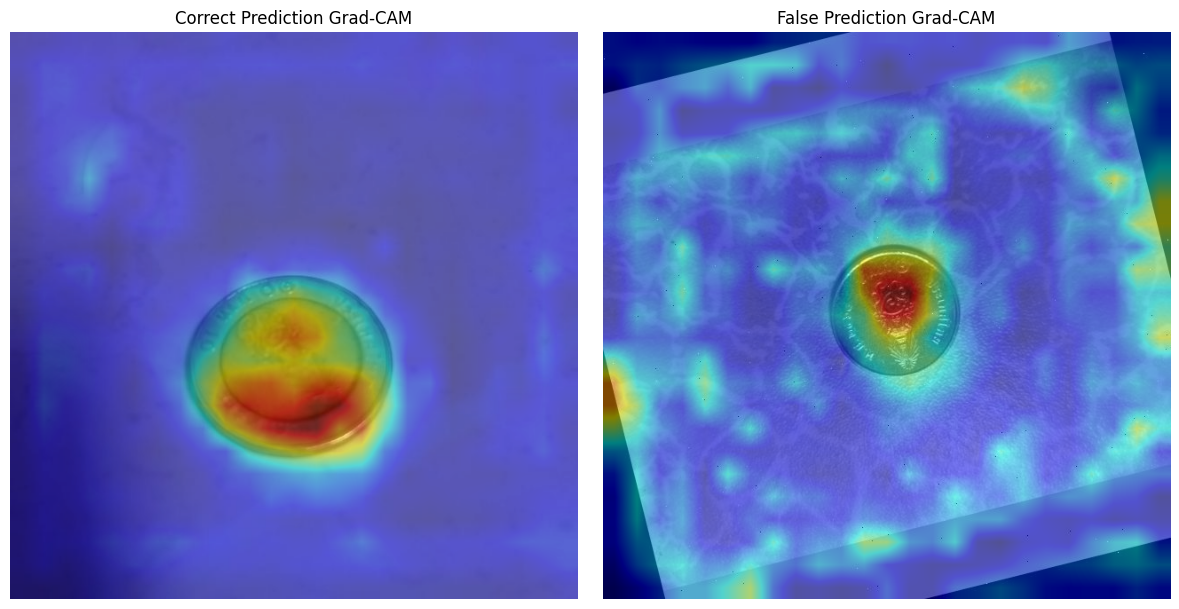

In [ ]:
target_layer = model.backbone.body.layer4[-1]

# for imgs, targets in val_loader:
#     img_tensor = imgs[0].to(device)
#     visualize_gradcam_backbone(img_tensor, target_layer, device)
#     break

correct_cam = visualize_gradcam_backbone(correct_img, target_layer, device, title="Correct Prediction Grad-CAM")
false_cam = visualize_gradcam_backbone(false_pos_img, target_layer, device, title="False Prediction Grad-CAM")

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(correct_cam)
plt.title("Correct Prediction Grad-CAM")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(false_cam)
plt.title("False Prediction Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()

C:\Users\louis\AppData\Local\Temp\ipykernel_7784\3851008350.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_int = torch.tensor(img * 255, dtype=torch.uint8)


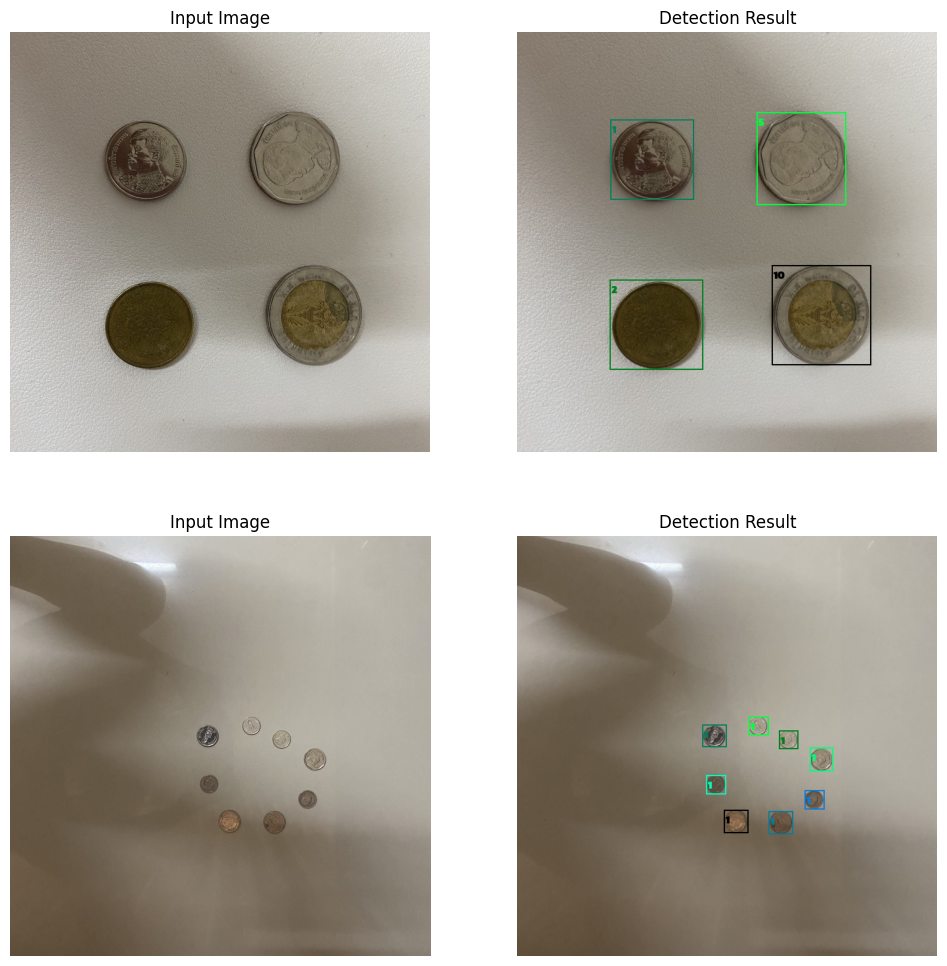

In [ ]:
best_checkpoint_path = "./best640.pt"
model = fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 6)

checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

fig, ax = plt.subplots(2, 2, figsize=(12, 12))
for i in range(2):
    for j in range(2):
        ax[i, j].axis("off")
ax[0, 0].set_title("Input Image")
ax[0, 1].set_title("Detection Result")
ax[1, 0].set_title("Input Image")
ax[1, 1].set_title("Detection Result")

classes = ['bg', 'objects', '1', '10', '2', '5']

img1 = Image.open("../test_images/test_1.jpg").convert("RGB")
img2 = Image.open("../test_images/test_6.jpg").convert("RGB")

transform = T.Compose([
    T.Resize((640, 640)),
    T.ToTensor(),
])

def draw_bbox_jaaa(img, model, device, classes):
    img = transform(img)

    img_cuda = img.to(device)
    with torch.no_grad():
        output = model([img_cuda])[0]

    pred_boxes = output["boxes"].cpu()
    pred_labels = output["labels"].cpu().numpy()
    pred_scores = output["scores"].cpu()

    pred_boxes, pred_labels, pred_scores = filter_nms(pred_boxes, pred_labels, pred_scores, iou_threshold=0.5, score_threshold=0.5)
    img_int = torch.tensor(img * 255, dtype=torch.uint8)

    return draw_bounding_boxes(
        img_int, pred_boxes, [classes[i] for i in pred_labels], width=2, font_size=16, font="./Kanit-Black.ttf"
    ).permute(1, 2, 0)

result1 = draw_bbox_jaaa(img1, model, device, classes)
result2 = draw_bbox_jaaa(img2, model, device, classes)
plt.imsave("results/draw_bbox1.png", result1.numpy())
plt.imsave("results/draw_bbox2.png", result2.numpy())

ax[0, 0].imshow(img1)
ax[0, 1].imshow(result1)
ax[1, 0].imshow(img2)
ax[1, 1].imshow(result2)




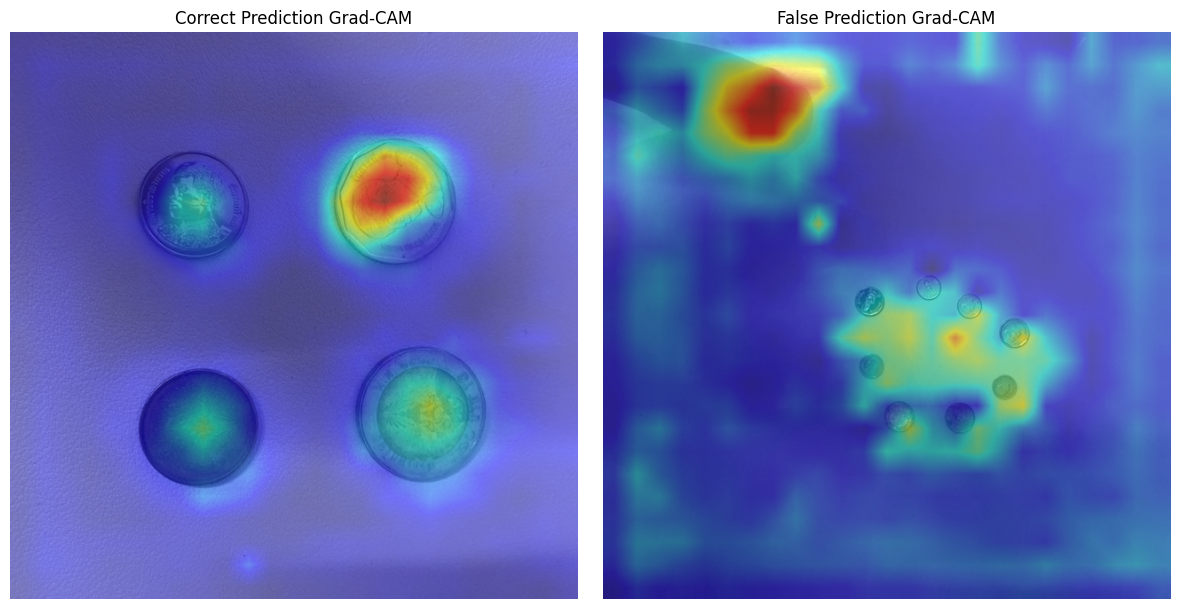

In [ ]:
target_layer = model.backbone.body.layer4[-1]

correct_cam = visualize_gradcam_backbone(transform(img1), target_layer, device, title="Grad-CAM")
false_cam = visualize_gradcam_backbone(transform(img2), target_layer, device, title="Grad-CAM")

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(correct_cam)
plt.title("Correct Prediction Grad-CAM")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(false_cam)
plt.title("False Prediction Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()